# College Scorecard: Higher Education Outcomes
## CS 4379G — Data Analysis & Visualization
### Jorge Jimenez | Spring 2026

## Research Question
Does paying more or attending a more selective school actually lead to better 
outcomes for students? This notebook analyzes tuition cost and selectivity 
as inputs against graduation rates and median earnings as outputs to determine 
which types of institutions offer the strongest return on investment.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('../data/Most-Recent-Cohorts-Institution.csv')

# See how big it is
print(df.shape)

C:\Users\Jorge\AppData\Local\Temp\ipykernel_14020\871932566.py:5: DtypeWarning: Columns (0: NPCURL, 1: INC_N, 2: DEP_STAT_N, 3: APPL_SCH_N, 4: RPY_1YR_N, 5: RPY_3YR_N, 6: RPY_7YR_N, 7: FIRSTGEN_RPY_7YR_N, 8: NOTFIRSTGEN_RPY_7YR_N, 9: AGE_ENTRY, 10: AGEGE24, 11: FAMINC, 12: MD_FAMINC, 13: PCT_WHITE, 14: PCT_BLACK, 15: PCT_ASIAN, 16: PCT_HISPANIC, 17: PCT_BA, 18: PCT_GRAD_PROF, 19: PCT_BORN_US, 20: MEDIAN_HH_INC, 21: POVERTY_RATE, 22: UNEMP_RATE, 23: LN_MEDIAN_HH_INC, 24: C150_L4_POOLED_SUPP, 25: C150_4_POOLED_SUPP, 26: C200_L4_POOLED_SUPP, 27: C200_4_POOLED_SUPP, 28: ALIAS, 29: T4APPROVALDATE, 30: RET_FT4_POOLED_SUPP, 31: RET_FTL4_POOLED_SUPP, 32: RET_PT4_POOLED_SUPP, 33: RET_PTL4_POOLED_SUPP, 34: TRANS_4_POOLED_SUPP, 35: TRANS_L4_POOLED_SUPP, 36: C100_4_POOLED_SUPP, 37: C100_L4_POOLED_SUPP, 38: OMAWDP6_FTFT_POOLED_SUPP, 39: OMAWDP8_FTFT_POOLED_SUPP, 40: OMENRYP8_FTFT_POOLED_SUPP, 41: OMENRAP8_FTFT_POOLED_SUPP, 42: OMENRUP8_FTFT_POOLED_SUPP, 43: OMAWDP6_PTFT_POOLED_SUPP, 44: OMAWDP8_PTF

(6322, 3308)


In [2]:
# These are the only columns we need
cols = [
    'INSTNM',           # School name
    'STABBR',           # State
    'CONTROL',          # 1=Public, 2=Private Nonprofit, 3=Private For-Profit
    'PREDDEG',          # Type of degree the school mainly gives out
    'ADM_RATE',         # Admission rate (how selective the school is)
    'SAT_AVG',          # Average SAT score
    'COSTT4_A',         # Average total cost of attendance per year
    'TUITIONFEE_IN',    # In-state tuition
    'C150_4',           # 6-year graduation rate
    'MD_EARN_WNE_P10',  # Median earnings 10 years after enrolling
    'UGDS'              # Total undergrad enrollment size
]

# Keep only those columns
df = df[cols]

# Check the new size
print(df.shape)

(6322, 11)


In [3]:
# Show the first 5 rows
df.head()

,INSTNM,STABBR,CONTROL,PREDDEG,ADM_RATE,SAT_AVG,COSTT4_A,TUITIONFEE_IN,C150_4,MD_EARN_WNE_P10,UGDS
0,Alabama A & M University,AL,1,3,0.5795,938.0,27153.0,10024.0,0.2403,40628.0,6124.0
1,University of Alabama at Birmingham,AL,1,3,0.8818,1258.0,28145.0,9098.0,0.6423,54501.0,11635.0
2,Amridge University,AL,2,3,NaN,NaN,NaN,7590.0,1.0000,37621.0,241.0
3,University of Alabama in Huntsville,AL,1,3,0.6857,1319.0,27392.0,12132.0,0.6429,61767.0,6591.0
4,Alabama State University,AL,1,3,0.9755,976.0,23586.0,11248.0,0.3034,34502.0,3477.0


In [4]:
# Check what data types each column is and how many values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6322 entries, 0 to 6321
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   INSTNM           6322 non-null   str    
 1   STABBR           6322 non-null   str    
 2   CONTROL          6322 non-null   int64  
 3   PREDDEG          6322 non-null   int64  
 4   ADM_RATE         1927 non-null   float64
 5   SAT_AVG          1038 non-null   float64
 6   COSTT4_A         3230 non-null   float64
 7   TUITIONFEE_IN    3662 non-null   float64
 8   C150_4           2283 non-null   float64
 9   MD_EARN_WNE_P10  5173 non-null   float64
 10  UGDS             5587 non-null   float64
dtypes: float64(7), int64(2), str(2)
memory usage: 741.8 KB


In [5]:
# Step 1: Filter to only 4-year degree schools
# PREDDEG == 3 means the school mainly gives out bachelor's degrees
df = df[df['PREDDEG'] == 3]
print("After filtering to 4-year schools:", df.shape)

# Step 2: Drop rows that are missing ANY of our 4 key metrics
# These are the columns your whole analysis depends on
df = df.dropna(subset=['COSTT4_A', 'ADM_RATE', 'C150_4', 'MD_EARN_WNE_P10'])
print("After dropping missing key metrics:", df.shape)

# Step 3: Map CONTROL numbers to readable labels
# Right now it's just 1, 2, 3 — let's make it human readable
df['institution_type'] = df['CONTROL'].map({
    1: 'Public',
    2: 'Private Nonprofit',
    3: 'Private For-Profit'
})

# Step 4: Create an ROI column
# This is earnings divided by cost — higher = better return on investment
df['roi'] = df['MD_EARN_WNE_P10'] / df['COSTT4_A']

print("Final shape:", df.shape)
print("\nInstitution type breakdown:")
print(df['institution_type'].value_counts())

After filtering to 4-year schools: (1959, 11)
After dropping missing key metrics: (1474, 11)
Final shape: (1474, 13)

Institution type breakdown:
institution_type
Private Nonprofit     920
Public                517
Private For-Profit     37
Name: count, dtype: int64


In [6]:
# Reset the index so rows are numbered cleanly from 0
df = df.reset_index(drop=True)

# Quick summary of our clean dataset
print("Clean dataset shape:", df.shape)
print("\nSample of key columns:")
df[['INSTNM', 'institution_type', 'COSTT4_A', 'ADM_RATE', 'C150_4', 'MD_EARN_WNE_P10', 'roi']].head(10)


Clean dataset shape: (1474, 13)

Sample of key columns:


,INSTNM,institution_type,COSTT4_A,ADM_RATE,C150_4,MD_EARN_WNE_P10,roi
0,Alabama A & M University,Public,27153.0,0.5795,0.2403,40628.0,1.496262
1,University of Alabama at Birmingham,Public,28145.0,0.8818,0.6423,54501.0,1.936436
2,University of Alabama in Huntsville,Public,27392.0,0.6857,0.6429,61767.0,2.254928
3,Alabama State University,Public,23586.0,0.9755,0.3034,34502.0,1.462817
4,The University of Alabama,Public,33382.0,0.7665,0.7337,59221.0,1.774040
5,Auburn University at Montgomery,Public,21353.0,0.9157,0.3260,44391.0,2.078912
6,Auburn University,Public,34919.0,0.4592,0.8195,65337.0,1.871102
7,Faulkner University,Private Nonprofit,37626.0,0.7307,0.3740,43457.0,1.154973
8,Huntingdon College,Private Nonprofit,40908.0,0.6949,0.4798,49601.0,1.212501
9,Heritage Christian University,Private Nonprofit,20909.0,0.9000,0.6667,42597.0,2.037257


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look clean and professional
sns.set_theme(style="whitegrid")

# Makes charts bigger and easier to read
plt.rcParams['figure.figsize'] = (10, 6)

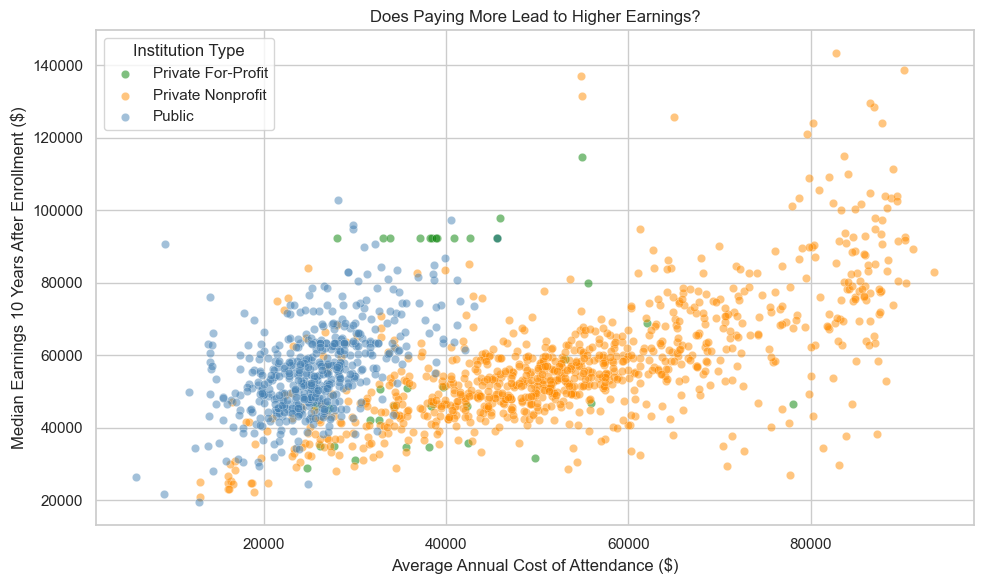


CAPTION: This scatter plot compares annual cost of attendance against median 
earnings 10 years after enrollment for 1,474 U.S. institutions. While there 
is a general positive trend — higher cost schools tend to produce higher 
earners — the relationship is not consistent across institution types. 
Private Nonprofit schools show the widest spread, suggesting that cost alone 
is not a reliable predictor of earnings outcomes.



In [8]:
# Chart 1: Cost vs. Median Earnings colored by institution type
fig, ax = plt.subplots()

# Plot each institution type separately so they get different colors
colors = {'Public': 'steelblue', 'Private Nonprofit': 'darkorange', 'Private For-Profit': 'green'}

for inst_type, group in df.groupby('institution_type'):
    ax.scatter(
        group['COSTT4_A'],          # x axis = cost
        group['MD_EARN_WNE_P10'],   # y axis = earnings
        label=inst_type,
        color=colors[inst_type],
        alpha=0.5,                  # makes dots slightly transparent so overlaps are visible
        edgecolors='white',
        linewidth=0.3
    )

# Labels and title
ax.set_xlabel('Average Annual Cost of Attendance ($)')
ax.set_ylabel('Median Earnings 10 Years After Enrollment ($)')
ax.set_title('Does Paying More Lead to Higher Earnings?')
ax.legend(title='Institution Type')

plt.tight_layout()
plt.savefig('../notebooks/chart1_cost_vs_earnings.png', dpi=150)
plt.show()

print("""
CAPTION: This scatter plot compares annual cost of attendance against median 
earnings 10 years after enrollment for 1,474 U.S. institutions. While there 
is a general positive trend — higher cost schools tend to produce higher 
earners — the relationship is not consistent across institution types. 
Private Nonprofit schools show the widest spread, suggesting that cost alone 
is not a reliable predictor of earnings outcomes.
""")

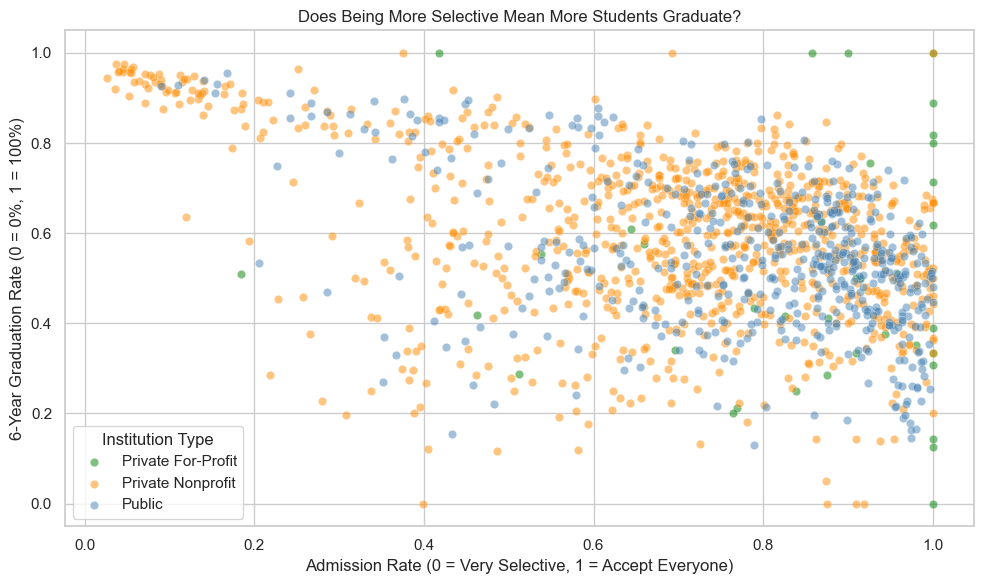


CAPTION: This scatter plot compares admission rate against 6-year graduation 
rate across 1,474 institutions. A clear negative trend emerges — schools that 
accept fewer students (lower admission rate) tend to graduate a higher 
percentage of them. However, there are notable exceptions, particularly among 
Public institutions, where some open-admission schools still achieve strong 
graduation outcomes.



In [9]:
# Chart 2: Admission Rate vs Graduation Rate
fig, ax = plt.subplots()

for inst_type, group in df.groupby('institution_type'):
    ax.scatter(
        group['ADM_RATE'],    # x axis = admission rate (0 = super selective, 1 = accept everyone)
        group['C150_4'],      # y axis = graduation rate (0 = nobody graduates, 1 = everyone graduates)
        label=inst_type,
        color=colors[inst_type],
        alpha=0.5,
        edgecolors='white',
        linewidth=0.3
    )

ax.set_xlabel('Admission Rate (0 = Very Selective, 1 = Accept Everyone)')
ax.set_ylabel('6-Year Graduation Rate (0 = 0%, 1 = 100%)')
ax.set_title('Does Being More Selective Mean More Students Graduate?')
ax.legend(title='Institution Type')

plt.tight_layout()
plt.savefig('../notebooks/chart2_selectivity_vs_graduation.png', dpi=150)
plt.show()

print("""
CAPTION: This scatter plot compares admission rate against 6-year graduation 
rate across 1,474 institutions. A clear negative trend emerges — schools that 
accept fewer students (lower admission rate) tend to graduate a higher 
percentage of them. However, there are notable exceptions, particularly among 
Public institutions, where some open-admission schools still achieve strong 
graduation outcomes.
""")


C:\Users\Jorge\AppData\Local\Temp\ipykernel_14020\3171366265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


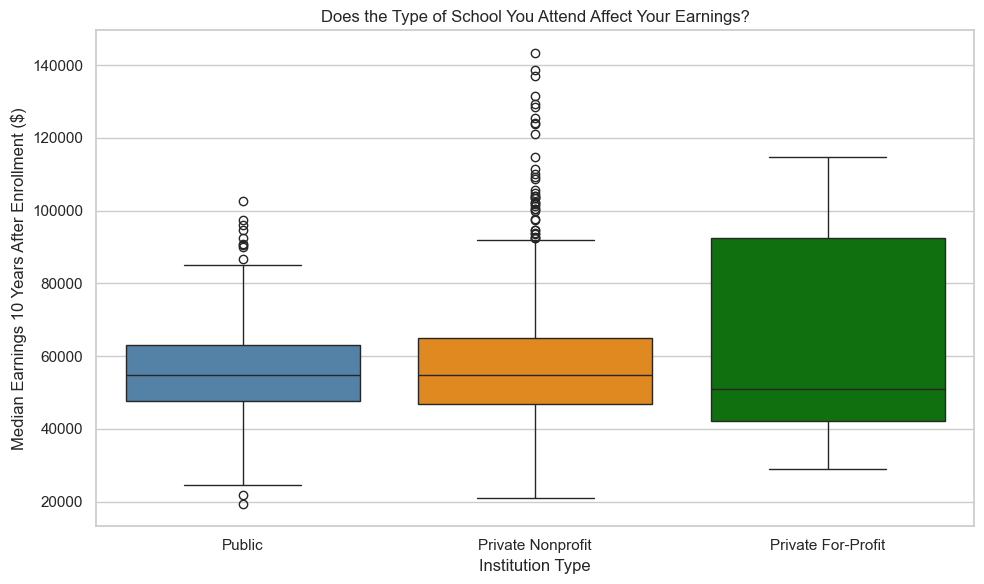


CAPTION: This boxplot compares median earnings 10 years after enrollment 
across the three institution types. Private Nonprofit schools show the 
highest median earnings but also the widest spread, meaning outcomes vary 
greatly between schools. Public institutions show consistently solid earnings 
with less variation. Private For-Profit schools tend to cluster at the lower 
end of the earnings spectrum, raising questions about their value proposition 
relative to cost.



In [10]:
# Chart 3: Boxplot of Median Earnings by Institution Type
fig, ax = plt.subplots()

# Define the order we want the boxes to appear
order = ['Public', 'Private Nonprofit', 'Private For-Profit']

sns.boxplot(
    data=df,
    x='institution_type',       # x axis = type of school
    y='MD_EARN_WNE_P10',        # y axis = earnings
    order=order,
    palette=colors,
    ax=ax
)

ax.set_xlabel('Institution Type')
ax.set_ylabel('Median Earnings 10 Years After Enrollment ($)')
ax.set_title('Does the Type of School You Attend Affect Your Earnings?')

plt.tight_layout()
plt.savefig('../notebooks/chart3_earnings_by_type.png', dpi=150)
plt.show()

print("""
CAPTION: This boxplot compares median earnings 10 years after enrollment 
across the three institution types. Private Nonprofit schools show the 
highest median earnings but also the widest spread, meaning outcomes vary 
greatly between schools. Public institutions show consistently solid earnings 
with less variation. Private For-Profit schools tend to cluster at the lower 
end of the earnings spectrum, raising questions about their value proposition 
relative to cost.
""")

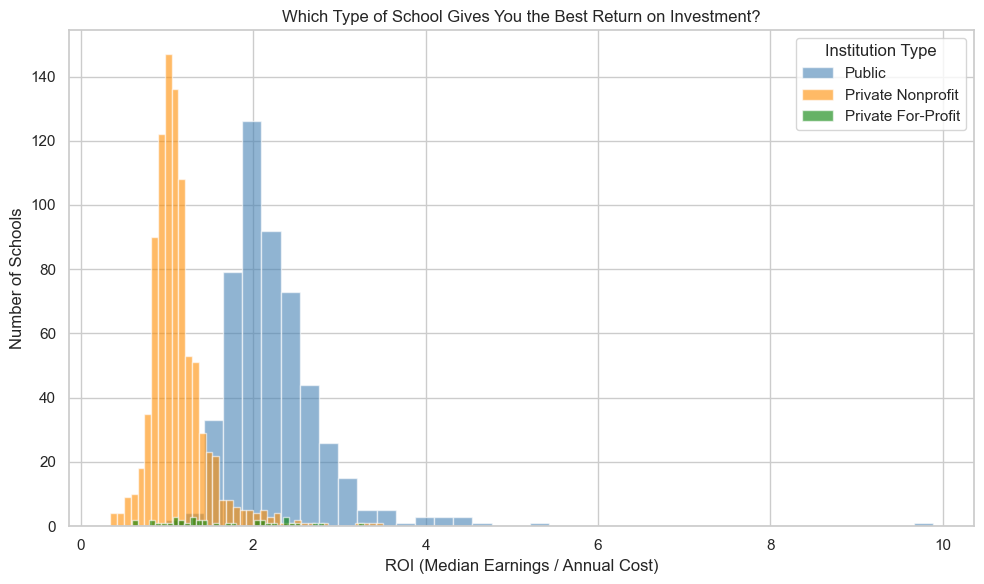


CAPTION: This histogram shows the distribution of return on investment (ROI), 
calculated as median earnings divided by annual cost of attendance, across 
all three institution types. Public schools consistently show higher ROI 
values than Private Nonprofit schools, suggesting that despite lower 
perceived prestige, public institutions often deliver stronger financial 
returns relative to their cost.



In [11]:
# Chart 4: Distribution of ROI by Institution Type
fig, ax = plt.subplots()

for inst_type in ['Public', 'Private Nonprofit', 'Private For-Profit']:
    subset = df[df['institution_type'] == inst_type]['roi']
    ax.hist(
        subset,
        bins=40,            # splits the data into 40 groups
        alpha=0.6,          # makes bars slightly transparent so they don't block each other
        label=inst_type,
        color=colors[inst_type],
        edgecolor='white'
    )

ax.set_xlabel('ROI (Median Earnings / Annual Cost)')
ax.set_ylabel('Number of Schools')
ax.set_title('Which Type of School Gives You the Best Return on Investment?')
ax.legend(title='Institution Type')

plt.tight_layout()
plt.savefig('../notebooks/chart4_roi_distribution.png', dpi=150)
plt.show()

print("""
CAPTION: This histogram shows the distribution of return on investment (ROI), 
calculated as median earnings divided by annual cost of attendance, across 
all three institution types. Public schools consistently show higher ROI 
values than Private Nonprofit schools, suggesting that despite lower 
perceived prestige, public institutions often deliver stronger financial 
returns relative to their cost.
""")

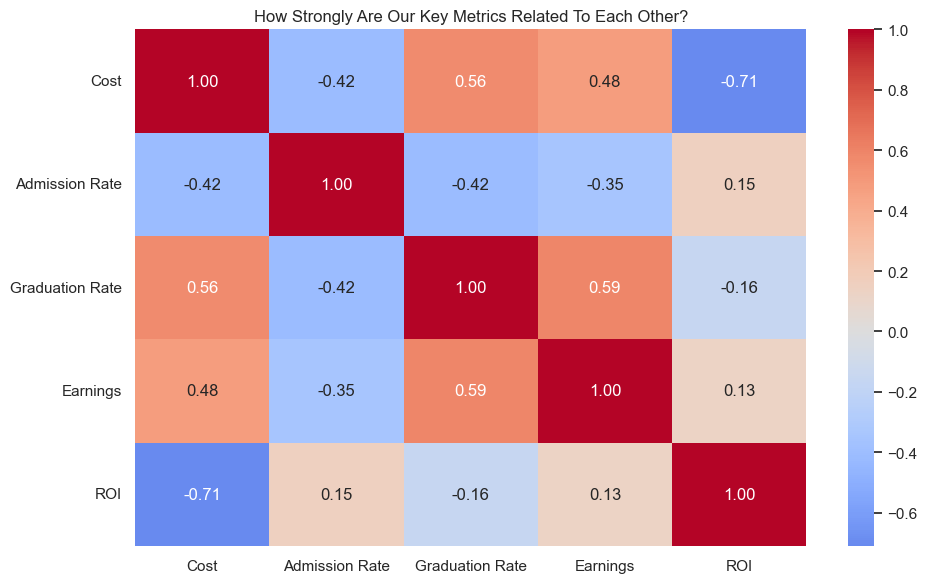


CAPTION: This heatmap shows the correlation between all key metrics in our 
analysis. Values close to 1.0 indicate a strong positive relationship, values 
close to -1.0 indicate a strong negative relationship, and values near 0 
indicate no relationship. Graduation rate and earnings show a moderate 
positive correlation, while admission rate shows a negative correlation with 
both graduation rate and earnings, confirming that more selective schools 
tend to produce better outcomes — though not always.



In [12]:
# Chart 5: Correlation Heatmap of Key Metrics
fig, ax = plt.subplots()

# Select only the numeric columns we care about
corr_cols = ['COSTT4_A', 'ADM_RATE', 'C150_4', 'MD_EARN_WNE_P10', 'roi']

# Calculate how strongly each column is related to every other column
corr_matrix = df[corr_cols].corr()

# Rename columns so they're readable on the chart
corr_matrix.columns = ['Cost', 'Admission Rate', 'Graduation Rate', 'Earnings', 'ROI']
corr_matrix.index = ['Cost', 'Admission Rate', 'Graduation Rate', 'Earnings', 'ROI']

sns.heatmap(
    corr_matrix,
    annot=True,          # shows the actual numbers inside each square
    fmt='.2f',           # rounds numbers to 2 decimal places
    cmap='coolwarm',     # red = strong positive, blue = strong negative
    center=0,            # white = no relationship
    ax=ax
)

ax.set_title('How Strongly Are Our Key Metrics Related To Each Other?')

plt.tight_layout()
plt.savefig('../notebooks/chart5_correlation_heatmap.png', dpi=150)
plt.show()

print("""
CAPTION: This heatmap shows the correlation between all key metrics in our 
analysis. Values close to 1.0 indicate a strong positive relationship, values 
close to -1.0 indicate a strong negative relationship, and values near 0 
indicate no relationship. Graduation rate and earnings show a moderate 
positive correlation, while admission rate shows a negative correlation with 
both graduation rate and earnings, confirming that more selective schools 
tend to produce better outcomes — though not always.
""")

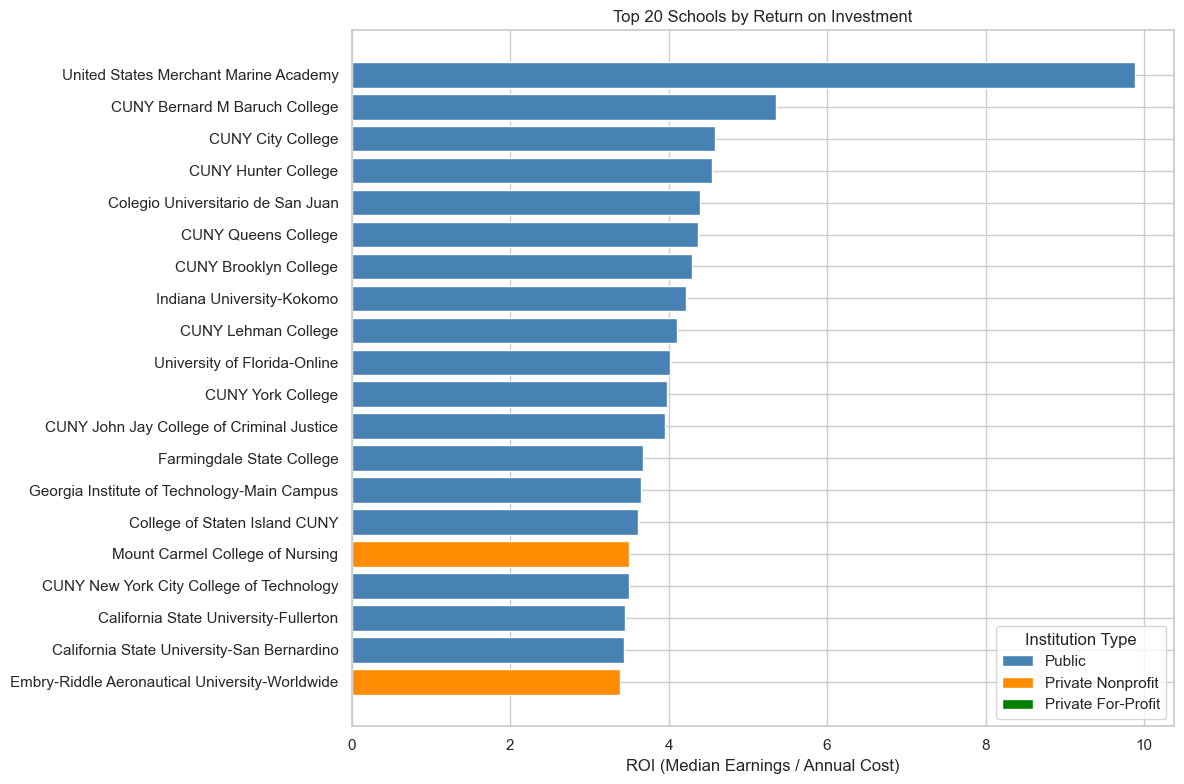


CAPTION: This horizontal bar chart displays the 20 institutions with the 
highest return on investment, calculated as median earnings divided by annual 
cost of attendance. Public institutions dominate the top 20, reinforcing the 
finding from Chart 4 that public schools consistently deliver stronger 
financial returns relative to their cost. This chart is particularly useful 
for prospective students who want to maximize their financial outcomes while 
minimizing educational debt.



In [13]:
# Chart 6: Top 20 Schools by ROI
fig, ax = plt.subplots(figsize=(12, 8))

# Sort schools by ROI and grab the top 20
top20 = df.nlargest(20, 'roi')[['INSTNM', 'roi', 'institution_type']].reset_index(drop=True)

# Create colors for each bar based on institution type
bar_colors = [colors[t] for t in top20['institution_type']]

# Create horizontal bar chart
ax.barh(
    top20['INSTNM'],    # y axis = school names
    top20['roi'],       # x axis = ROI score
    color=bar_colors,
    edgecolor='white'
)

# Flip so highest ROI is at the top
ax.invert_yaxis()

ax.set_xlabel('ROI (Median Earnings / Annual Cost)')
ax.set_title('Top 20 Schools by Return on Investment')

# Add a legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Public'),
    Patch(facecolor='darkorange', label='Private Nonprofit'),
    Patch(facecolor='green', label='Private For-Profit')
]
ax.legend(handles=legend_elements, title='Institution Type')

plt.tight_layout()
plt.savefig('../notebooks/chart6_top20_roi.png', dpi=150)
plt.show()

print("""
CAPTION: This horizontal bar chart displays the 20 institutions with the 
highest return on investment, calculated as median earnings divided by annual 
cost of attendance. Public institutions dominate the top 20, reinforcing the 
finding from Chart 4 that public schools consistently deliver stronger 
financial returns relative to their cost. This chart is particularly useful 
for prospective students who want to maximize their financial outcomes while 
minimizing educational debt.
""")

In [14]:
print("""
SUMMARY OF FINDINGS & HYPOTHESES FOR FURTHER EXPLORATION
=========================================================

DATASET:
- Started with 6,322 institutions
- Filtered to 1,474 four-year schools with complete data on our key metrics
- Three institution types: Public (517), Private Nonprofit (920), For-Profit (37)

KEY FINDINGS FROM EDA:
1. Cost does not reliably predict earnings — expensive schools are spread
   all over the earnings spectrum (Chart 1)

2. More selective schools generally graduate more students, but there are 
   many exceptions — some open admission schools have strong graduation 
   rates (Chart 2)

3. Private Nonprofit schools have the highest earning outliers but also 
   the most inconsistency — public schools are more predictable (Chart 3)

4. Public schools consistently deliver the highest ROI — meaning graduates 
   earn more relative to what they paid (Chart 4)

5. Graduation rate is the strongest predictor of earnings — stronger than 
   cost or selectivity (Chart 5)

6. The top 20 ROI schools are dominated by public institutions, with 
   specialized schools like Maritime Academies leading the list (Chart 6)

HYPOTHESES FOR FURTHER EXPLORATION:
- A student attending a public school in their home state likely gets 
  the best financial return due to lower in-state tuition
- Graduation rate may be a better signal of school quality than 
  admission rate or cost
- Private Nonprofit schools may only be worth the premium cost for a 
  small number of elite institutions
- State level differences in public school quality may explain some 
  of the variation we see
""")


SUMMARY OF FINDINGS & HYPOTHESES FOR FURTHER EXPLORATION

DATASET:
- Started with 6,322 institutions
- Filtered to 1,474 four-year schools with complete data on our key metrics
- Three institution types: Public (517), Private Nonprofit (920), For-Profit (37)

KEY FINDINGS FROM EDA:
1. Cost does not reliably predict earnings — expensive schools are spread
   all over the earnings spectrum (Chart 1)

2. More selective schools generally graduate more students, but there are 
   many exceptions — some open admission schools have strong graduation 
   rates (Chart 2)

3. Private Nonprofit schools have the highest earning outliers but also 
   the most inconsistency — public schools are more predictable (Chart 3)

4. Public schools consistently deliver the highest ROI — meaning graduates 
   earn more relative to what they paid (Chart 4)

5. Graduation rate is the strongest predictor of earnings — stronger than 
   cost or selectivity (Chart 5)

6. The top 20 ROI schools are dominated by pu